In [1]:
from pathlib import Path
from time import time
from urllib.request import urlretrieve

import pandas as pd
import pandas.io.sql as psql
import pyarrow.parquet as pq
from IPython.display import display
from sqlalchemy import create_engine, text

# Load Data

In [2]:
DATA_URL = (
    "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2025-01.parquet"
)
DATA_DIR = Path("../data")
PARQUET_PATH = DATA_DIR / "yellow_tripdata_2025-01.parquet"

DATA_DIR.mkdir(parents=True, exist_ok=True)

if PARQUET_PATH.exists():
    print(f"Reusing existing file: {PARQUET_PATH}")
else:
    print(f"Downloading {DATA_URL}")
    urlretrieve(DATA_URL, PARQUET_PATH)
    print(f"Saved file to {PARQUET_PATH}")

PARQUET_PATH

Reusing existing file: ../data/yellow_tripdata_2025-01.parquet


PosixPath('../data/yellow_tripdata_2025-01.parquet')

## Read parquet file into a pandas DataFrame

In [3]:
df = pd.read_parquet(PARQUET_PATH)
print(f"Loaded {len(df):,} rows and {len(df.columns)} columns from {PARQUET_PATH.name}")
df.head(5)

Loaded 3,475,226 rows and 20 columns from yellow_tripdata_2025-01.parquet


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,1.0,N,229,237,1,10.0,3.5,0.5,3.00,0.0,1.0,18.00,2.5,0.0,0.0
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,1.0,N,236,237,1,5.1,3.5,0.5,2.02,0.0,1.0,12.12,2.5,0.0,0.0
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,1.0,N,141,141,1,5.1,3.5,0.5,2.00,0.0,1.0,12.10,2.5,0.0,0.0
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,1.0,N,244,244,2,7.2,1.0,0.5,0.00,0.0,1.0,9.70,0.0,0.0,0.0
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,1.0,N,244,116,2,5.8,1.0,0.5,0.00,0.0,1.0,8.30,0.0,0.0,0.0


# Clean Data

In [4]:
#check for missing values
df.isna().sum()

VendorID                      0
tpep_pickup_datetime          0
tpep_dropoff_datetime         0
passenger_count          540149
trip_distance                 0
RatecodeID               540149
store_and_fwd_flag       540149
PULocationID                  0
DOLocationID                  0
payment_type                  0
fare_amount                   0
extra                         0
mta_tax                       0
tip_amount                    0
tolls_amount                  0
improvement_surcharge         0
total_amount                  0
congestion_surcharge     540149
Airport_fee              540149
cbd_congestion_fee            0
dtype: int64

store_and_fwd_flag, RatecodeID, congestion_surcharge, and Airport_fee can be ignored from the features.


## Calculate Duration

In [5]:
import matplotlib.pyplot as plt

df_clean = df.copy()

#duration isn't in the dataset, so we need to calculate it
df_clean["duration_minutes"] = (
    df_clean["tpep_dropoff_datetime"] - df_clean["tpep_pickup_datetime"]
).dt.total_seconds() / 60

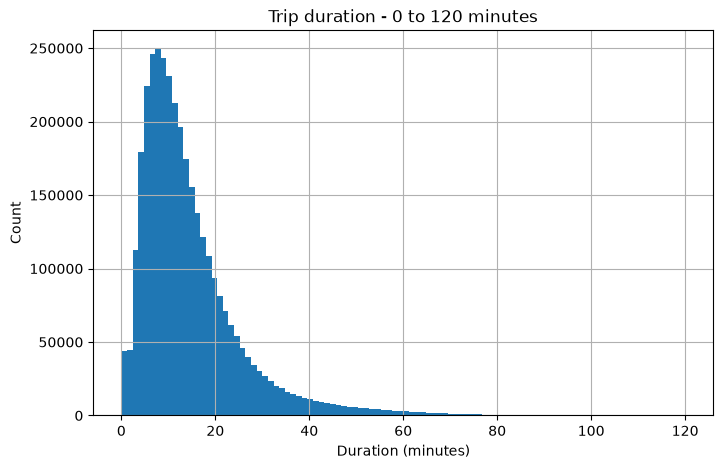

In [6]:
#Duration histogram
plt.figure(figsize=(8, 5))
df_clean[df_clean["duration_minutes"].between(0, 120)]["duration_minutes"].hist(bins=100) #put the min max values to limit the histogram to 0-120 minutes
plt.xlabel("Duration (minutes)")
plt.ylabel("Count")
plt.title("Trip duration - 0 to 120 minutes")
plt.show()


In [7]:
df_clean["duration_minutes"].describe()

count    3.475226e+06
mean     1.501812e+01
std      3.871358e+01
min     -5.147232e+04
25%      7.283333e+00
50%      1.170000e+01
75%      1.833333e+01
max      5.626317e+03
Name: duration_minutes, dtype: float64

In [8]:
df_clean["duration_minutes"].quantile([0.95, 0.99, 0.999])

0.950    36.200000
0.990    58.916667
0.999    98.262917
Name: duration_minutes, dtype: float64

In [9]:
df_clean = df_clean[
    (df_clean["duration_minutes"] >= 1) & (df_clean["duration_minutes"] <= 60)
]
print(df_clean.shape)
print(df_clean["duration_minutes"].describe())

(3403248, 21)
count    3.403248e+06
mean     1.422852e+01
std      9.763400e+00
min      1.000000e+00
25%      7.383333e+00
50%      1.171667e+01
75%      1.818333e+01
max      6.000000e+01
Name: duration_minutes, dtype: float64


## Trip Distance

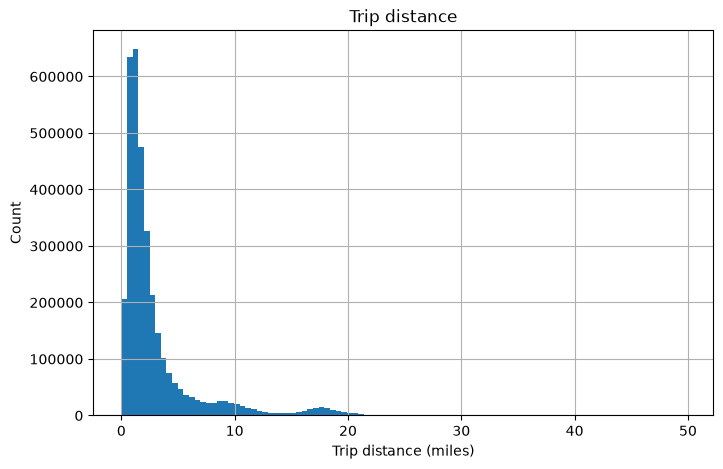

In [18]:
#Trips distance
plt.figure(figsize=(8, 5))
df_clean[df_clean["trip_distance"].between(0, 50)]["trip_distance"].hist(bins=100)
plt.xlabel("Trip distance (miles)")
plt.ylabel("Count")
plt.title("Trip distance")
plt.show()

In [19]:
df_clean["trip_distance"].describe()

count    3.379470e+06
mean     5.815017e+00
std      5.714764e+02
min      0.000000e+00
25%      1.000000e+00
50%      1.680000e+00
75%      3.070000e+00
max      2.764236e+05
Name: trip_distance, dtype: float64

In [20]:
df_clean["trip_distance"].quantile([0.95, 0.99, 0.999])

0.950    11.07000
0.990    19.03000
0.999    27.30531
Name: trip_distance, dtype: float64

In [21]:
df_clean = df_clean[
    (df_clean["trip_distance"] > 0) & (df_clean["trip_distance"] <= 100)
]

In [22]:
df_clean["trip_distance"].describe()

count    3.315663e+06
mean     3.065254e+00
std      3.878051e+00
min      1.000000e-02
25%      1.020000e+00
50%      1.700000e+00
75%      3.110000e+00
max      9.488000e+01
Name: trip_distance, dtype: float64

## Passenger Count

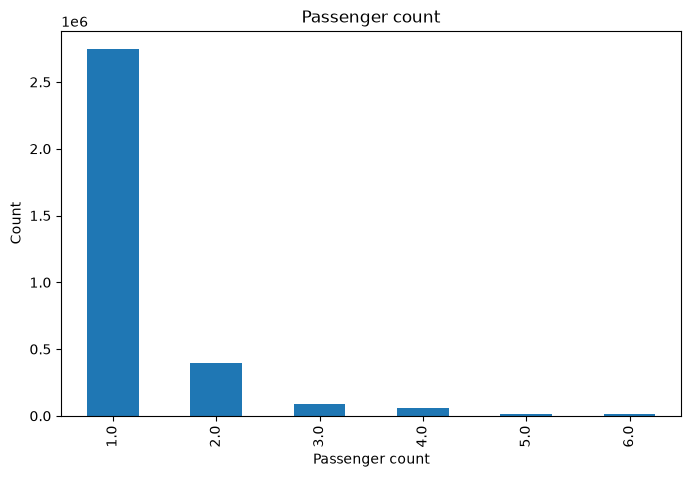

In [23]:
plt.figure(figsize=(8, 5))
df_clean["passenger_count"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Passenger count")
plt.ylabel("Count")
plt.title("Passenger count")
plt.show()

In [24]:
df_clean["passenger_count"].isna().mean() * 100  # % of rows affected

np.float64(0.0)

In [25]:
#impute with the most common value
df_clean["passenger_count"] = df_clean["passenger_count"].fillna(df_clean["passenger_count"].mode()[0])

In [26]:
#check again
df_clean["passenger_count"].isna().mean() * 100  # % of rows affected

np.float64(0.0)

In [27]:
#sanity check
#check for missing values
df_clean.isna().sum()

VendorID                      0
tpep_pickup_datetime          0
tpep_dropoff_datetime         0
passenger_count               0
trip_distance                 0
RatecodeID               486450
store_and_fwd_flag       486450
PULocationID                  0
DOLocationID                  0
payment_type                  0
fare_amount                   0
extra                         0
mta_tax                       0
tip_amount                    0
tolls_amount                  0
improvement_surcharge         0
total_amount                  0
congestion_surcharge     486450
Airport_fee              486450
cbd_congestion_fee            0
duration_minutes              0
dtype: int64

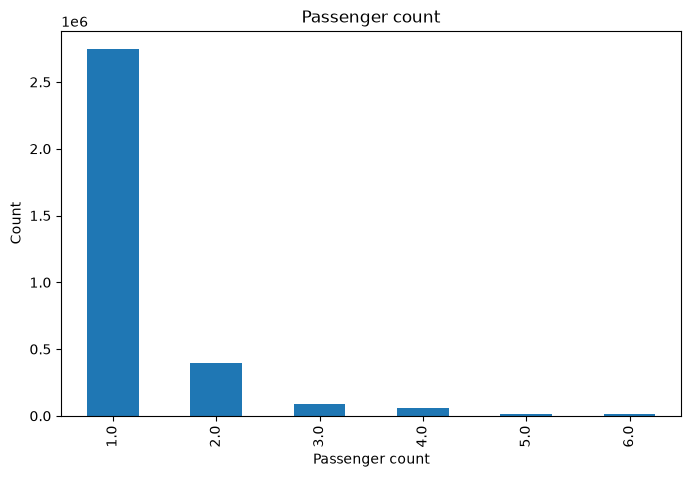

In [28]:
plt.figure(figsize=(8, 5))
df_clean["passenger_count"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Passenger count")
plt.ylabel("Count")
plt.title("Passenger count")
plt.show()

In [29]:
df_clean["passenger_count"].describe()

count    3.315663e+06
mean     1.262097e+00
std      6.937914e-01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      6.000000e+00
Name: passenger_count, dtype: float64

In [30]:
#clean up the dataset by removing trips with 0 passengers and trips with more than 6 passengers
df_clean = df_clean[(df_clean["passenger_count"] > 0) & (df_clean["passenger_count"] <= 6)]
print(df_clean.shape)

(3315663, 21)


## Pick up hour and day of week

In [32]:
df_clean["pickup_hour"] = df_clean["tpep_pickup_datetime"].dt.hour
df_clean["pickup_dayofweek"] = df_clean["tpep_pickup_datetime"].dt.dayofweek

df_clean.head(5)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,duration_minutes,pickup_hour,pickup_dayofweek
0,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.60,1.0,N,229,237,1,...,3.00,0.0,1.0,18.00,2.5,0.0,0.0,8.350000,0,2
1,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.50,1.0,N,236,237,1,...,2.02,0.0,1.0,12.12,2.5,0.0,0.0,2.550000,0,2
2,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.60,1.0,N,141,141,1,...,2.00,0.0,1.0,12.10,2.5,0.0,0.0,1.950000,0,2
3,2,2025-01-01 00:14:27,2025-01-01 00:20:01,3.0,0.52,1.0,N,244,244,2,...,0.00,0.0,1.0,9.70,0.0,0.0,0.0,5.566667,0,2
4,2,2025-01-01 00:21:34,2025-01-01 00:25:06,3.0,0.66,1.0,N,244,116,2,...,0.00,0.0,1.0,8.30,0.0,0.0,0.0,3.533333,0,2


## Change Location IDs to Boroughs

In [33]:
import pandas as pd

zones = pd.read_csv("https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv")
print(zones.head())
print(zones["Borough"].unique())

   LocationID        Borough                     Zone service_zone
0           1            EWR           Newark Airport          EWR
1           2         Queens              Jamaica Bay    Boro Zone
2           3          Bronx  Allerton/Pelham Gardens    Boro Zone
3           4      Manhattan            Alphabet City  Yellow Zone
4           5  Staten Island            Arden Heights    Boro Zone
<ArrowStringArray>
[          'EWR',        'Queens',         'Bronx',     'Manhattan',
 'Staten Island',      'Brooklyn',       'Unknown',             nan]
Length: 8, dtype: str


In [34]:
df_clean = df_clean.merge(
    zones[["LocationID", "Borough"]].rename(columns={"Borough": "PUBorough"}),
    left_on="PULocationID", right_on="LocationID", how="left"
).drop(columns=["LocationID"])

df_clean = df_clean.merge(
    zones[["LocationID", "Borough"]].rename(columns={"Borough": "DOBorough"}),
    left_on="DOLocationID", right_on="LocationID", how="left"
).drop(columns=["LocationID"])

In [35]:
df_clean[["PUBorough", "DOBorough"]].isna().sum()

PUBorough     397
DOBorough    9568
dtype: int64

Fill NAN values with Unknown

In [36]:
df_clean["PUBorough"] = df_clean["PUBorough"].fillna("Unknown")
df_clean["DOBorough"] = df_clean["DOBorough"].fillna("Unknown")

df_clean[["PUBorough", "DOBorough"]].isna().sum()

PUBorough    0
DOBorough    0
dtype: int64

## Data Preprocessing

In [37]:
#transform the data into a list of dictionaries

from sklearn.feature_extraction import DictVectorizer
from sklearn.model_selection import train_test_split

categorical = ["PUBorough", "DOBorough"]
numerical = ["trip_distance", "passenger_count", "pickup_hour", "pickup_dayofweek"]

# cast categoricals to string BEFORE building the dicts
df_clean[categorical] = df_clean[categorical].astype(str)

In [38]:
# split first
train_df, val_df = train_test_split(df_clean, test_size=0.3, random_state=42)
train_df_small = train_df.sample(n=1_000_000, random_state=42)


In [46]:
# build one dict per row, for each split
#train_dicts = train_df_small[categorical + numerical].to_dict(orient="records")
train_dicts = train_df[categorical + numerical].to_dict(orient="records")
val_dicts = val_df[categorical + numerical].to_dict(orient="records")

train_dicts[0]
val_dicts[0]

{'PUBorough': 'Manhattan',
 'DOBorough': 'Manhattan',
 'trip_distance': 1.63,
 'passenger_count': 1.0,
 'pickup_hour': 8,
 'pickup_dayofweek': 6}

In [47]:
# fit ONLY on train, then transform both
dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)
X_val = dv.transform(val_dicts)


In [48]:
print(X_train[:5])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 30 stored elements and shape (5, 18)>
  Coords	Values
  (0, 3)	1.0
  (0, 10)	1.0
  (0, 14)	1.0
  (0, 15)	3.0
  (0, 16)	23.0
  (0, 17)	2.39
  (1, 3)	1.0
  (1, 10)	1.0
  (1, 14)	3.0
  (1, 15)	0.0
  (1, 16)	15.0
  (1, 17)	1.3
  (2, 1)	1.0
  (2, 10)	1.0
  (2, 14)	1.0
  (2, 15)	0.0
  (2, 16)	17.0
  (2, 17)	3.93
  (3, 3)	1.0
  (3, 10)	1.0
  (3, 14)	1.0
  (3, 15)	6.0
  (3, 16)	1.0
  (3, 17)	0.98
  (4, 3)	1.0
  (4, 10)	1.0
  (4, 14)	1.0
  (4, 15)	1.0
  (4, 16)	23.0
  (4, 17)	1.6


In [49]:
#y_train = train_df_small["duration_minutes"].values
y_train = train_df["duration_minutes"].values
y_val = val_df["duration_minutes"].values

In [50]:
X_train.shape

X_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 13925784 stored elements and shape (2320964, 18)>

In [51]:
y_train.shape

(2320964,)

## Train Model

In [52]:
#Train RF

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error
import time

t0 = time.time()
model = RandomForestRegressor(n_estimators=50, max_depth=20, min_samples_leaf=5, random_state=42, n_jobs=-1) #uses all available cores
model.fit(X_train, y_train)
print(f"fit: {time.time() - t0:.1f}s")

fit: 808.6s


## Prediction and RMSE

In [53]:
y_pred = model.predict(X_val)
rmse = root_mean_squared_error(y_val, y_pred)
print(f"Validation RMSE: {rmse:.3f}")

Validation RMSE: 4.300


# MLflow

In [56]:
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("nyc-taxi-duration")

with mlflow.start_run():
    params = {
        "n_estimators": 100,
        "max_depth": 20,
        "min_samples_leaf": 5,
        "random_state": 42,
        "n_jobs": -1,
    }
    model = RandomForestRegressor(**params)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    rmse = root_mean_squared_error(y_val, y_pred)

    mlflow.log_params(params)
    mlflow.log_param("train_rows", X_train.shape[0])
    mlflow.log_metric("rmse", rmse)
    mlflow.sklearn.log_model(
        model,
        name="model",
        skops_trusted_types=["sklearn.tree._tree.Tree"],  # <- only change: added this
    )

    print(f"Validation RMSE: {rmse:.3f}")

2026/09/30 21:10:44 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Validation RMSE: 4.298


Start the UI from the folder "notebooks" (where this notebook is):

In [ ]:
uv run mlflow ui --backend-store-uri sqlite:///mlflow.db --port 5000

Open http://127.0.0.1:5000 and find the nyc-taxi-duration experiment. Confirm the run shows the correct params (n_estimators, max_depth, min_samples_leaf, train_rows), the rmse metric, and a model artifact